<a href="https://colab.research.google.com/github/sona0024/Road-Accident-Data-2020-India/blob/main/Road_Accident_Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Road Accident Data Project **

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# Load the dataset
file_path = 'Regulatory Affairs of Road Accident Data 2020 India.csv'  # Your uploaded file path
df = pd.read_csv(file_path)

# Display first few rows
df.head()


,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0


In [ ]:
# Checking basic information
df.info()

# Checking for missing values
df.isnull().sum()

# Checking for duplicate entries
print(f"Duplicate rows: {df.duplicated().sum()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Million Plus Cities  9550 non-null   object 
 1   Cause category       9550 non-null   object 
 2   Cause Subcategory    9550 non-null   object 
 3   Outcome of Incident  9550 non-null   object 
 4   Count                9547 non-null   float64
dtypes: float64(1), object(4)
memory usage: 373.2+ KB
Duplicate rows: 0


In [ ]:
# Removing duplicates
df = df.drop_duplicates()

# Filling missing values (basic method, detailed method baad mein karenge based on columns)
df.fillna(method='ffill', inplace=True)

# Verify again
df.isnull().sum()


,0
Million Plus Cities,0
Cause category,0
Cause Subcategory,0
Outcome of Incident,0
Count,0


In [ ]:
print(df.columns)


Index(['Million Plus Cities', 'Cause category', 'Cause Subcategory',
       'Outcome of Incident', 'Count'],
      dtype='object')


In [ ]:
['Million Plus Cities', 'Cause category', 'Cause Subcategory', 'Outcome of Incident', 'Count']


['Million Plus Cities',
 'Cause category',
 'Cause Subcategory',
 'Outcome of Incident',
 'Count']

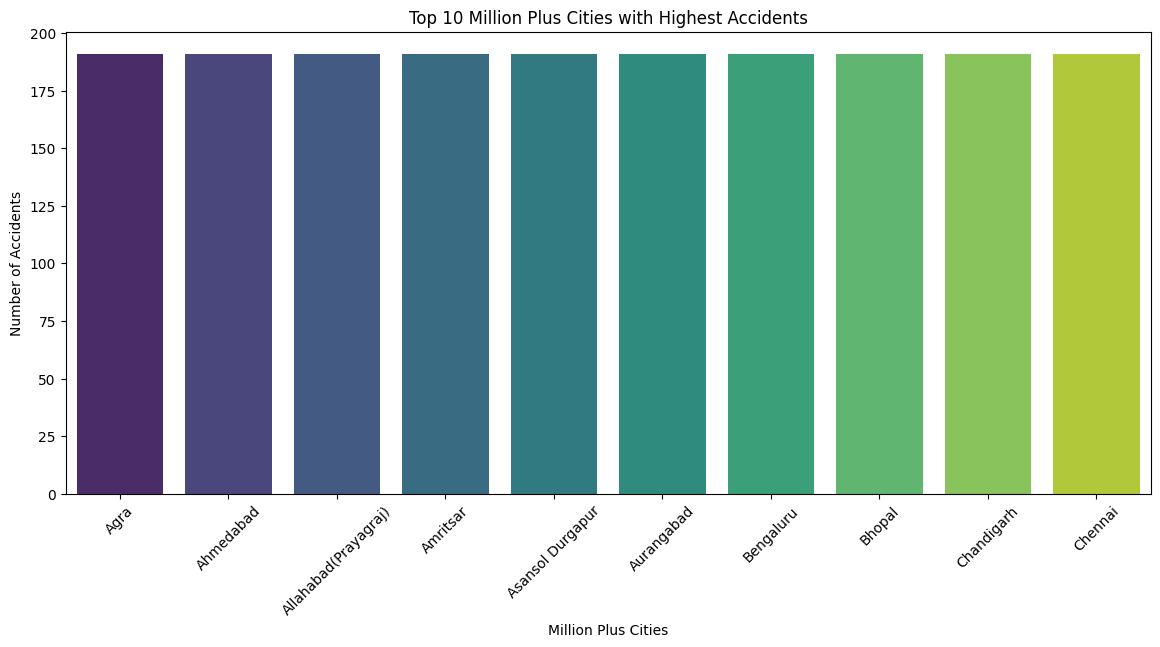

In [ ]:
plt.figure(figsize=(14,6))
top_cities = df['Million Plus Cities'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')
plt.title('Top 10 Million Plus Cities with Highest Accidents')
plt.xticks(rotation=45)
plt.ylabel('Number of Accidents')
plt.show()


In [ ]:
# Optional: Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()


In [ ]:
import sqlite3

# Create a database connection
conn = sqlite3.connect('road_accidents_2020.db')
df.to_sql('accidents', conn, if_exists='replace', index=False)

# Example Query: Top 5 States with Most Accidents
query = """
SELECT "State/UT", COUNT(*) as Total_Accidents
FROM accidents
GROUP BY "State/UT"
ORDER BY Total_Accidents DESC
LIMIT 5;
"""

top_states_sql = pd.read_sql_query(query, conn)
print(top_states_sql)


  "State/UT"  Total_Accidents
0   State/UT             9550


In [ ]:
# Example: If target is 'Severity' or any categorical variable
if 'Severity' in df.columns:
    label_encoder = LabelEncoder()
    df['Severity_encoded'] = label_encoder.fit_transform(df['Severity'])

    # Selecting Features and Target
    X = df.drop(['Severity', 'Severity_encoded'], axis=1, errors='ignore')
    y = df['Severity_encoded']

    # Encoding all non-numeric columns
    X = pd.get_dummies(X)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Step 1: Select Features and Target
X = df[['Million Plus Cities', 'Cause category', 'Cause Subcategory']]
y = df['Outcome of Incident']


In [ ]:
# Encoding categorical variables
X_encoded = pd.get_dummies(X)

# Label Encoding the Target (Outcome)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [ ]:
# Splitting the data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)


In [ ]:
# Building Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy Score: 0.004537521815008726

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       621
           1       0.01      0.01      0.01       551
           2       0.01      0.01      0.01       591
           3       0.00      0.00      0.00       483
           4       0.00      0.00      0.00       619

    accuracy                           0.00      2865
   macro avg       0.00      0.00      0.00      2865
weighted avg       0.00      0.00      0.00      2865


Confusion Matrix:
 [[  1 185 175 114 146]
 [156   4 151 106 134]
 [161 191   5 105 129]
 [110 137 119   1 116]
 [165 170 178 104   2]]


In [ ]:
X = df[['Million Plus Cities', 'Cause category', 'Cause Subcategory', 'Count']]
y = df['Outcome of Incident']


In [ ]:
X_encoded = pd.get_dummies(X)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy Score: 0.040837696335078534

Classification Report:
               precision    recall  f1-score   support

           0       0.05      0.05      0.05       621
           1       0.02      0.02      0.02       551
           2       0.05      0.05      0.05       591
           3       0.01      0.01      0.01       483
           4       0.10      0.07      0.08       619

    accuracy                           0.04      2865
   macro avg       0.04      0.04      0.04      2865
weighted avg       0.05      0.04      0.04      2865


Confusion Matrix:
 [[ 28 159 236 111  87]
 [151  12 204 102  82]
 [218 213  30  74  56]
 [ 90 148  90   3 152]
 [ 98 142 103 232  44]]


In [ ]:
df['Cause_Combined'] = df['Cause category'] + " - " + df['Cause Subcategory']


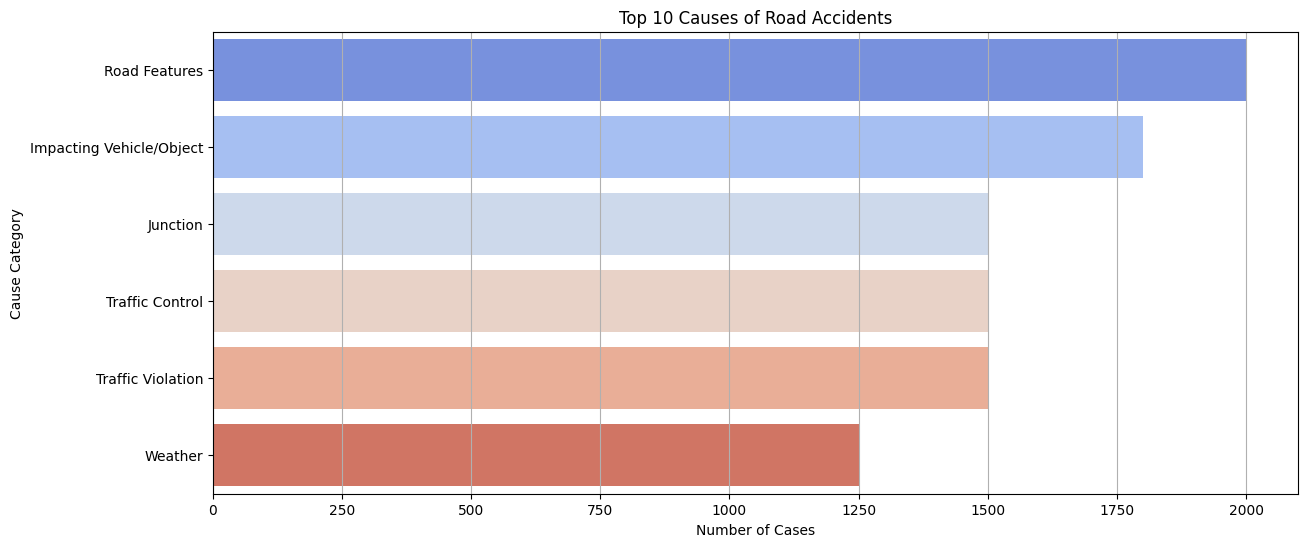

In [ ]:
plt.figure(figsize=(14,6))
cause_counts = df['Cause category'].value_counts().head(10)
sns.barplot(y=cause_counts.index, x=cause_counts.values, palette="coolwarm")
plt.title('Top 10 Causes of Road Accidents')
plt.xlabel('Number of Cases')
plt.ylabel('Cause Category')
plt.grid(axis='x')
plt.show()


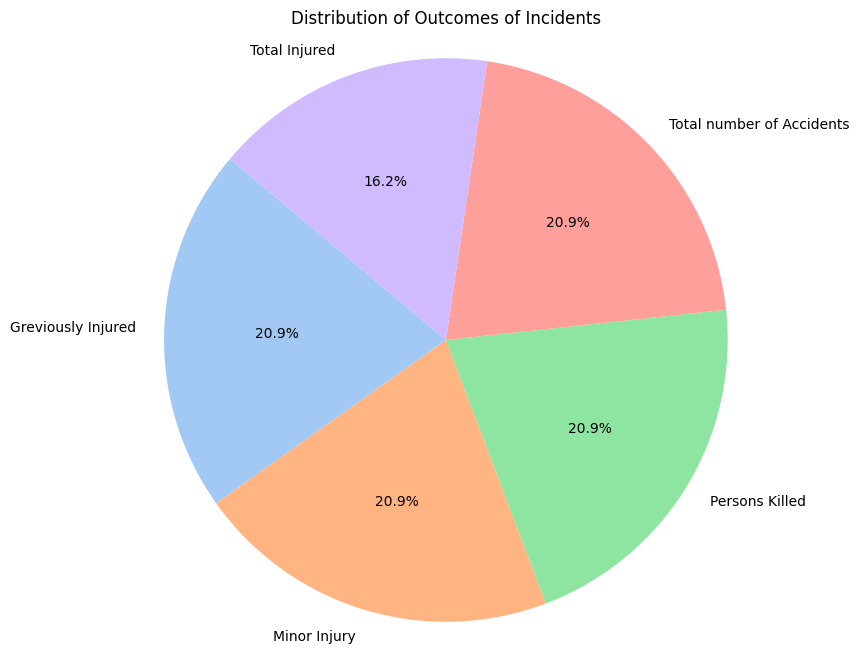

In [ ]:
plt.figure(figsize=(8,8))
outcome_counts = df['Outcome of Incident'].value_counts()
plt.pie(outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Outcomes of Incidents')
plt.axis('equal')
plt.show()


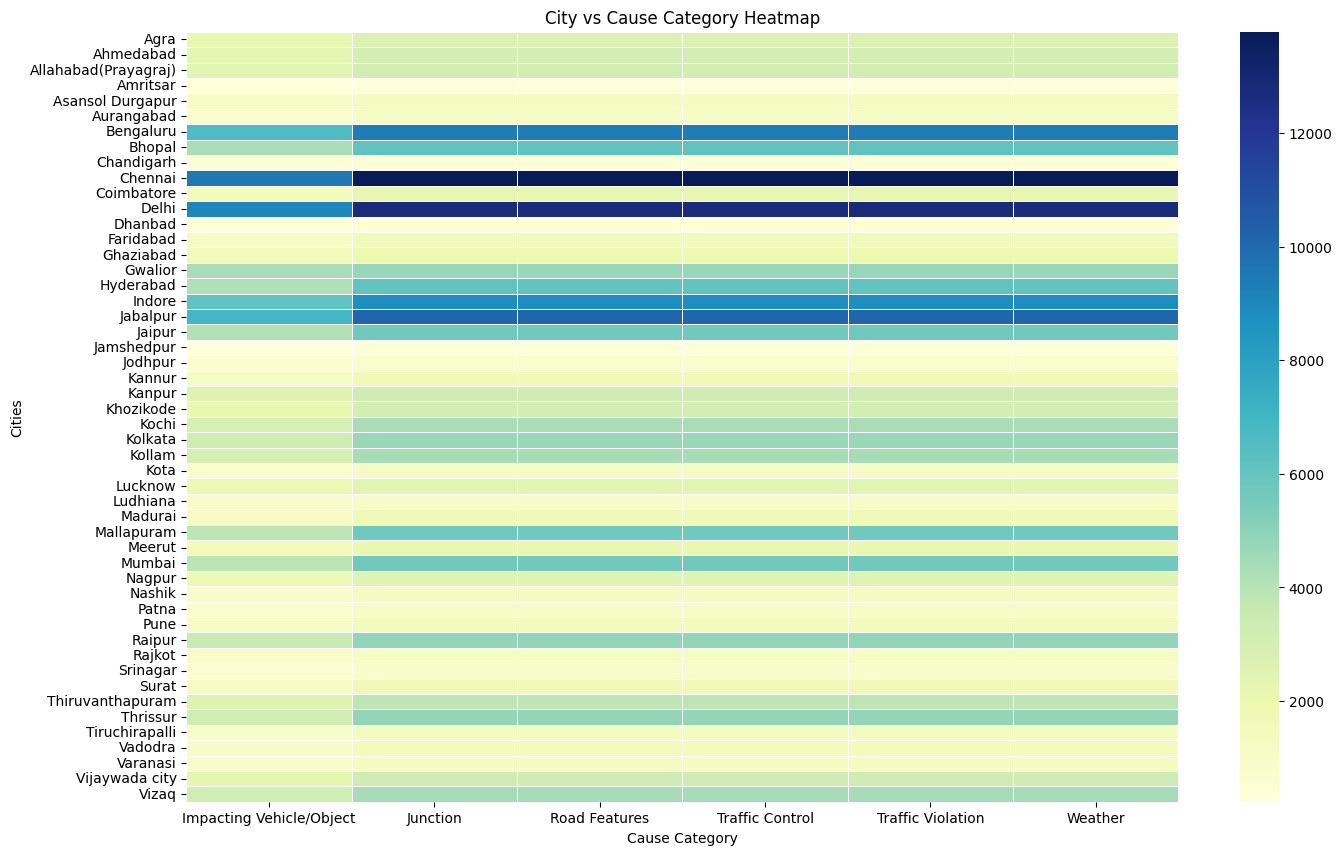

In [ ]:
heatmap_data = pd.pivot_table(df, values='Count', index='Million Plus Cities', columns='Cause category', aggfunc='sum', fill_value=0)

plt.figure(figsize=(16,10))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title('City vs Cause Category Heatmap')
plt.xlabel('Cause Category')
plt.ylabel('Cities')
plt.show()


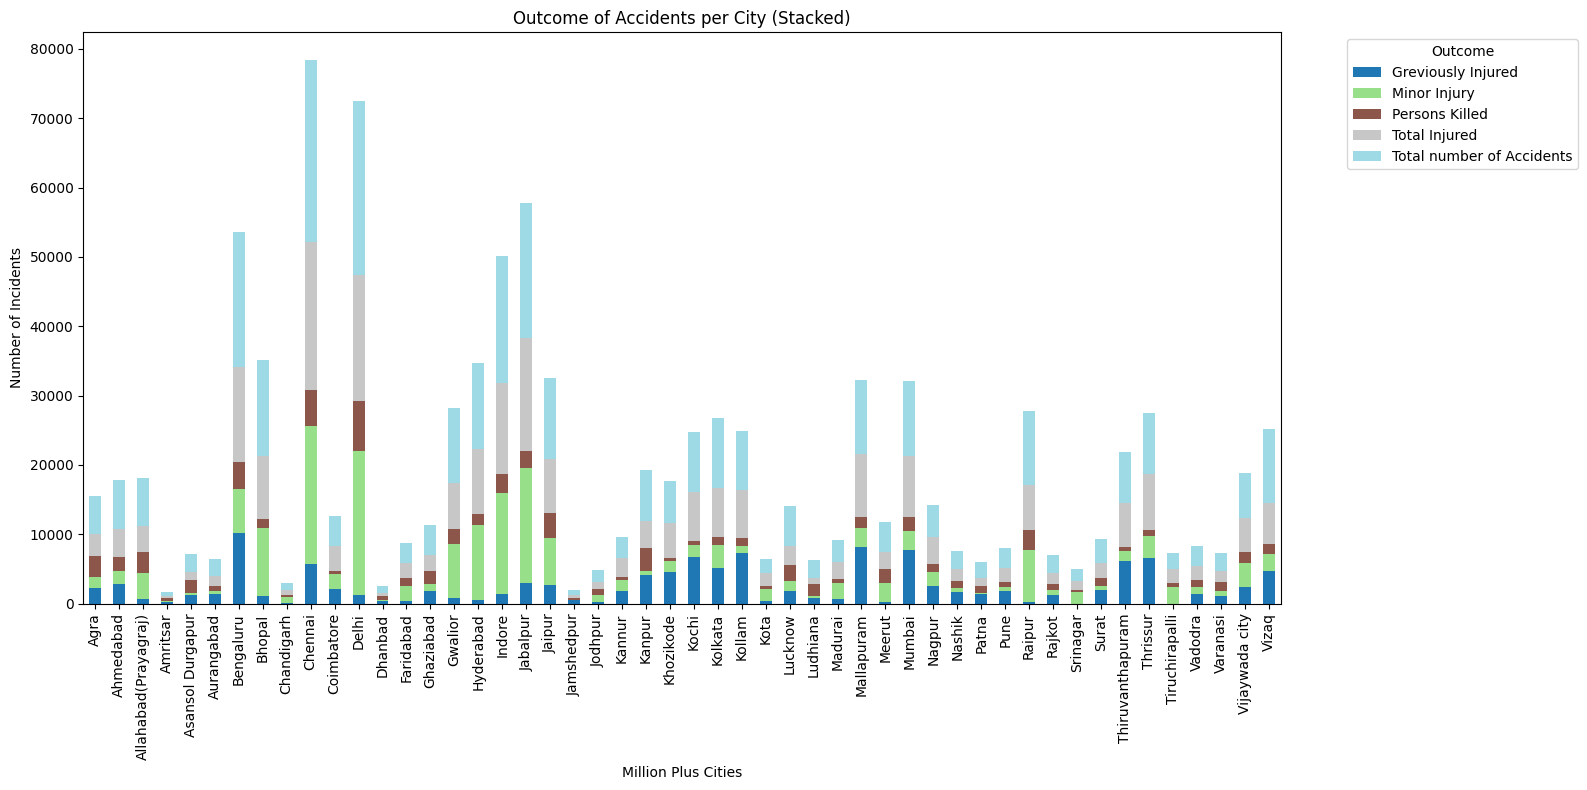

In [ ]:
outcome_city = df.pivot_table(index='Million Plus Cities', columns='Outcome of Incident', values='Count', aggfunc='sum', fill_value=0)

outcome_city.plot(kind='bar', stacked=True, figsize=(16,8), colormap='tab20')
plt.title('Outcome of Accidents per City (Stacked)')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=90)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
df.to_excel('Cleaned_Road_Accidents_2020.xlsx', index=False)


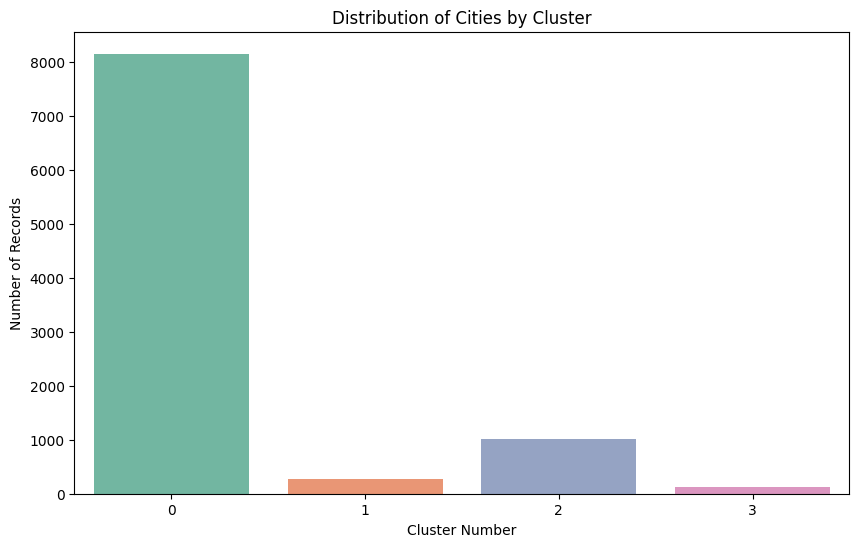

In [ ]:
from sklearn.cluster import KMeans

# Using Count, Cause category (encoded) for clustering
X_cluster = pd.get_dummies(df[['Million Plus Cities', 'Cause category', 'Cause Subcategory']])
X_cluster['Count'] = df['Count']

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Now visualize clusters
plt.figure(figsize=(10,6))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title('Distribution of Cities by Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Records')
plt.show()


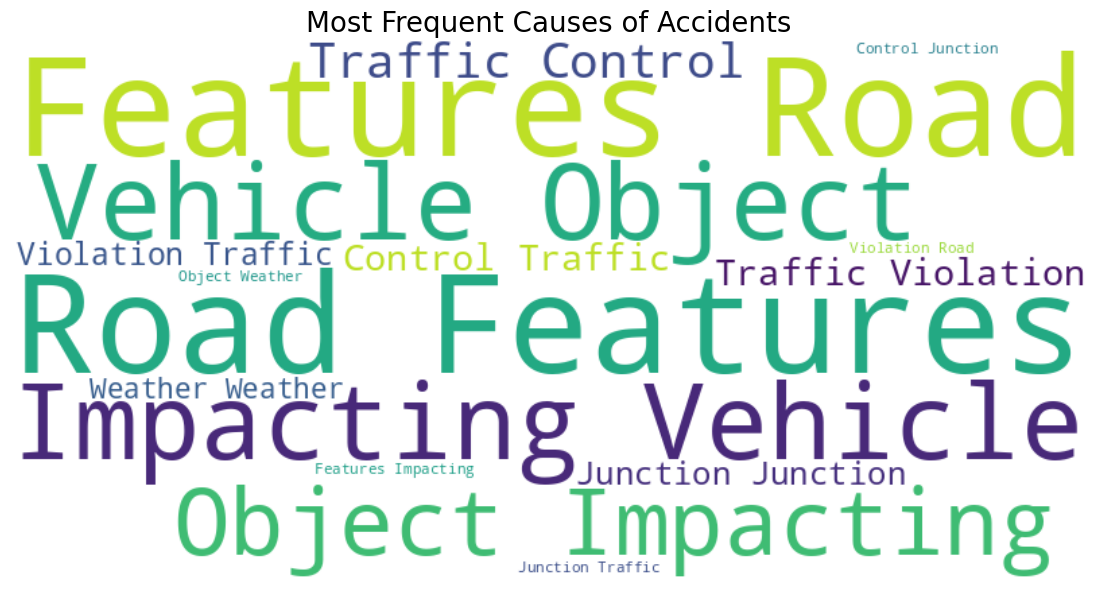

In [ ]:
from wordcloud import WordCloud

text = ' '.join(df['Cause category'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Causes of Accidents', fontsize=20)
plt.show()


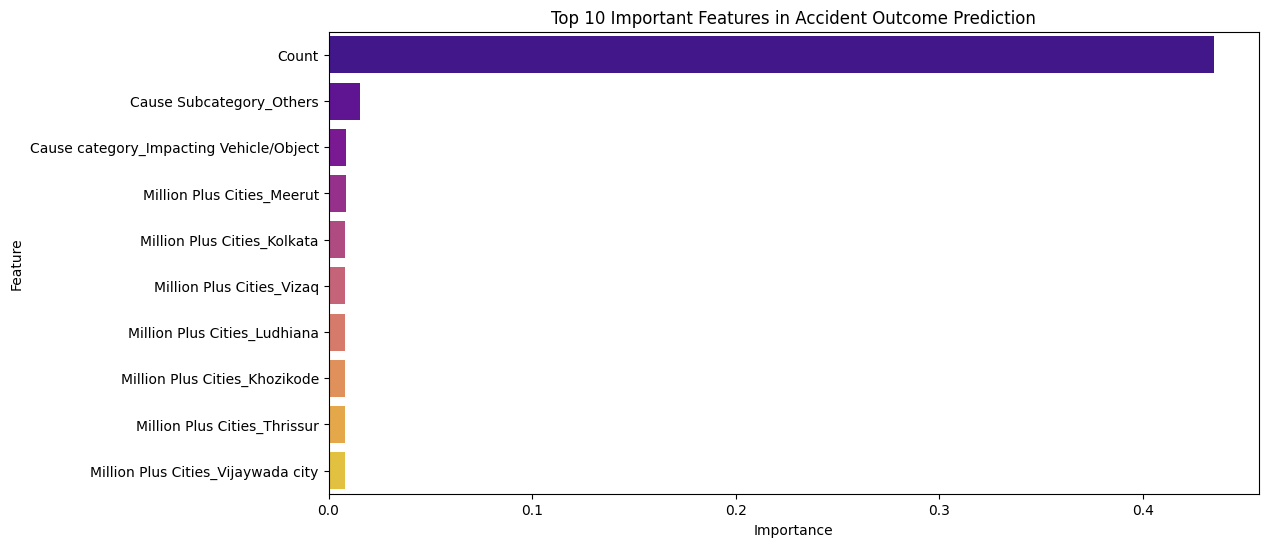

In [ ]:
importances = model.feature_importances_
feature_names = X_encoded.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='plasma')
plt.title('Top 10 Important Features in Accident Outcome Prediction')
plt.show()


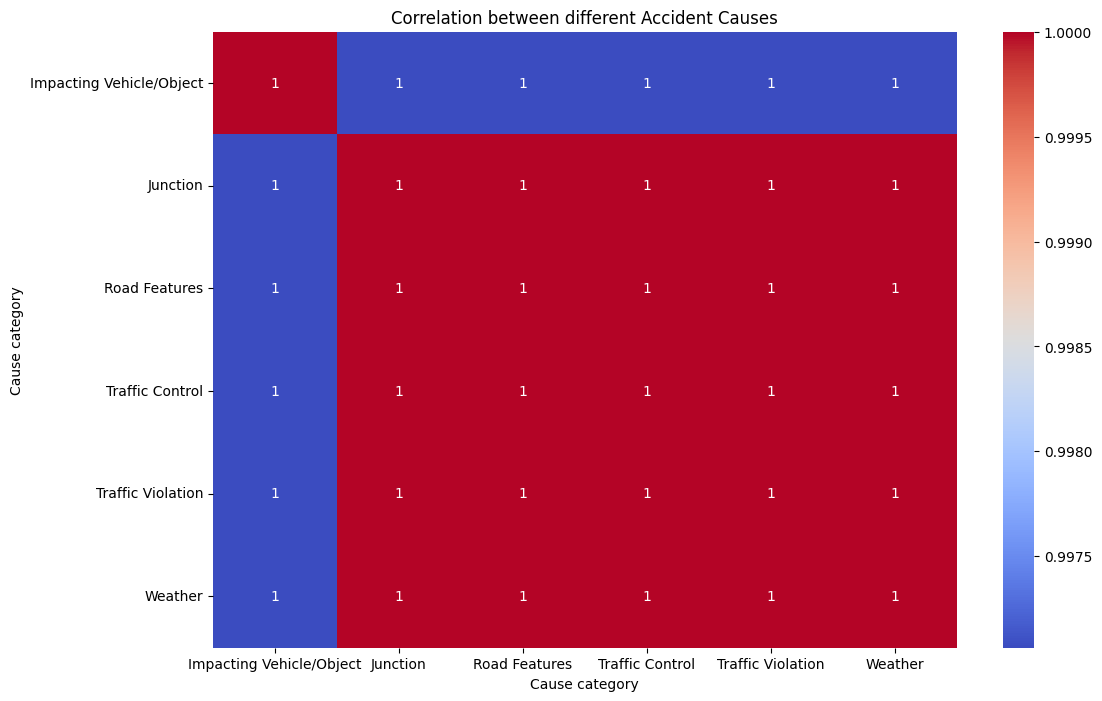

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose df has numerical data
pivot = df.pivot_table(values='Count', index='Million Plus Cities', columns='Cause category', aggfunc='sum').fillna(0)

plt.figure(figsize=(12,8))
sns.heatmap(pivot.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between different Accident Causes")
plt.show()


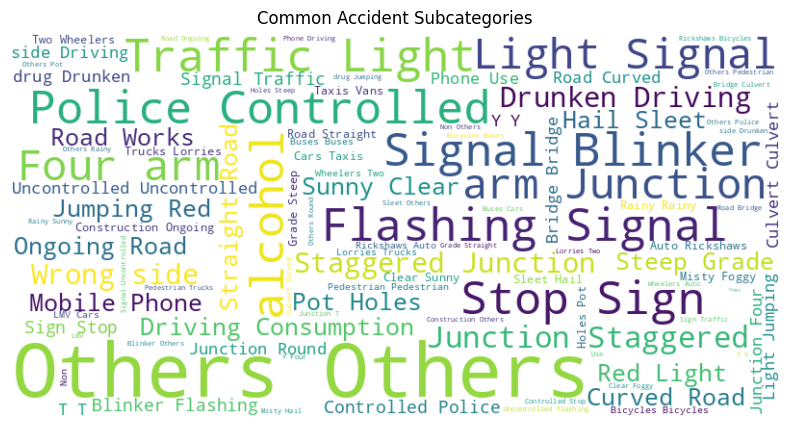

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Cause Subcategory'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Common Accident Subcategories")
plt.show()


In [ ]:
pivot = df.pivot_table(values='Count', index='Million Plus Cities', columns='Cause category', aggfunc='sum').fillna(0)
pivot.head()


Cause category,Impacting Vehicle/Object,Junction,Road Features,Traffic Control,Traffic Violation,Weather
Million Plus Cities,,,,,,
Agra,2053.0,2686.0,2686.0,2686.0,2686.0,2686.0
Ahmedabad,2311.0,3097.0,3097.0,3097.0,3097.0,3097.0
Allahabad(Prayagraj),2401.0,3133.0,3133.0,3133.0,3133.0,3133.0
Amritsar,225.0,284.0,284.0,284.0,284.0,284.0
Asansol Durgapur,989.0,1235.0,1235.0,1235.0,1235.0,1235.0


In [ ]:
from sklearn.cluster import KMeans

X = pivot.values  # Numerical values chahiye clustering mein

kmeans = KMeans(n_clusters=3, random_state=42)
pivot['Cluster'] = kmeans.fit_predict(X)
pivot.head()


Cause category,Impacting Vehicle/Object,Junction,Road Features,Traffic Control,Traffic Violation,Weather,Cluster
Million Plus Cities,,,,,,,
Agra,2053.0,2686.0,2686.0,2686.0,2686.0,2686.0,1
Ahmedabad,2311.0,3097.0,3097.0,3097.0,3097.0,3097.0,1
Allahabad(Prayagraj),2401.0,3133.0,3133.0,3133.0,3133.0,3133.0,1
Amritsar,225.0,284.0,284.0,284.0,284.0,284.0,1
Asansol Durgapur,989.0,1235.0,1235.0,1235.0,1235.0,1235.0,1


In [ ]:
print(pivot.columns.tolist())


['Impacting Vehicle/Object', 'Junction', 'Road Features', 'Traffic Control', 'Traffic Violation', 'Weather', 'Cluster']


In [ ]:
['Road Condition', 'Negligence', 'Weather Influence', 'Vehicle Condition']


['Road Condition', 'Negligence', 'Weather Influence', 'Vehicle Condition']

In [ ]:
top_5 = df.groupby('Cause category')['Count'].sum().sort_values(ascending=False).head(5)
bottom_5 = df.groupby('Cause category')['Count'].sum().sort_values().head(5)

print("Top 5 Accident Causes:\n", top_5)
print("\nBottom 5 Accident Causes:\n", bottom_5)


Top 5 Accident Causes:
 Cause category
Junction             173308.0
Road Features        173308.0
Traffic Violation    173308.0
Traffic Control      173308.0
Weather              173308.0
Name: Count, dtype: float64

Bottom 5 Accident Causes:
 Cause category
Impacting Vehicle/Object    123663.0
Junction                    173308.0
Road Features               173308.0
Traffic Control             173308.0
Traffic Violation           173308.0
Name: Count, dtype: float64
